Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
from linearmodels.panel import PooledOLS
from linearmodels.panel import PanelOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

Import des données

In [2]:
data = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\données_caracteristiques_communes.csv", index_col=0)
data['codecommune'] = data['codecommune'].astype(str).str.zfill(5)

# correction de la variable pbac
data['pbac'] = (data['pbac'] - data['psup']).clip(lower=0)

data.head()

C:\Users\yancr\AppData\Local\Temp\ipykernel_20456\184722120.py:1: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\données_caracteristiques_communes.csv", index_col=0)


,codecommune,Annee,pop,propf,prop014,prop1539,prop4059,prop60p,petranger,pcapi,...,pbac,psup,revmoy,vote_EG_pres,abstention_pres,vote_RN_pres,vote_EG_leg,abstention_leg,vote_RN_leg,typologie_urbaine
0,01001,1995,662,0.471756,0.268702,0.280916,0.258015,0.192366,0.016320,0.294118,...,0.044811,0.073113,12110.340,0.076056,0.201285,0.225352,NaN,NaN,NaN,Rural non périurbain
1,01001,1996,678,0.468657,0.270149,0.270149,0.265672,0.194030,0.017366,0.297521,...,0.045872,0.075688,11530.236,NaN,NaN,NaN,NaN,NaN,NaN,Rural non périurbain
2,01001,1997,695,0.467930,0.272595,0.259475,0.271137,0.196793,0.016997,0.298387,...,0.046875,0.080357,12207.807,NaN,NaN,NaN,0.098639,0.337607,0.20068,Rural non périurbain
3,01001,1998,711,0.465714,0.272857,0.250000,0.278571,0.198571,0.018006,0.305882,...,0.049892,0.082429,12892.058,NaN,NaN,NaN,NaN,NaN,NaN,Rural non périurbain
4,01001,1999,728,0.463687,0.273743,0.240223,0.284916,0.201117,0.018945,0.307692,...,0.050847,0.084746,12839.338,NaN,NaN,NaN,NaN,NaN,NaN,Rural non périurbain


# Elections Présidentielles

## Première partie : Evaluer l'évolution du vote pour le Rassemblement National entre 1995 et 2022 selon le type de communes

### Modélisation

Modèle naïf utilisé : 

$$VoteRN_{it} = \alpha_i + \gamma_t + \sum_{\tau \in \{2002, 2007, 2012, 2017, 2022\}} \beta_{\tau} (Typologie_i \times \mathbb{1}_{t=\tau}) + \epsilon_{it}$$

Modèle avec contrôles : 

$$VoteRN_{it} = \alpha_i + \gamma_t + \sum_{\tau \in \{2002, 2007, 2012, 2017, 2022\}} \widetilde{\beta}_{\tau} (Typologie_i \times \mathbb{1}_{t=\tau}) + \delta X_{it} + \eta_{it}$$

### Estimation du modèle naif

Selection des variables

In [3]:
df_modele_naif = data.dropna(subset=['vote_RN_pres', 'typologie_urbaine', 'Annee', 'codecommune']).copy()

Création des interactions typologie x annee

In [4]:
# Liste des années (en excluant 1995 qui sera notre référence)
annees_elections = sorted([y for y in df_modele_naif['Annee'].unique() if y > 1995])

# Liste des typologies (en excluant 'Urbain dense' qui est la référence)
typologies_commune = [t for t in df_modele_naif['typologie_urbaine'].unique() if t != 'Urbain dense']

# On crée une colonne pour chaque (Typologie x Année)
interaction_cols = []

for typologie in typologies_commune:
    for annee in annees_elections:
        col_name = f"inter_{typologie.replace(' ', '_')}_{annee}"
        # La variable vaut 1 si la commune appartient à la typo ET que c'est l'année T, sinon 0
        df_modele_naif[col_name] = ((df_modele_naif['typologie_urbaine'] == typologie) & (df_modele_naif['Annee'] == annee)).astype(int)
        interaction_cols.append(col_name)

Passage des données en panel

In [5]:
df_modele_naif = df_modele_naif.set_index(['codecommune', 'Annee'])

Estimation du modèle naïf

In [6]:
formula_inter = 'vote_RN_pres ~ 1 + ' + ' + '.join(interaction_cols) + ' + EntityEffects + TimeEffects'

mod_inter = PanelOLS.from_formula(formula_inter, data=df_modele_naif, drop_absorbed=True)
res_inter = mod_inter.fit(cov_type='clustered', cluster_entity=True)

print("=== MODÈLE : ÉVOLUTION PAR RAPPORT À 1995 (RÉFÉRENCE : URBAIN DENSE) ===")
print(res_inter.summary)

=== MODÈLE : ÉVOLUTION PAR RAPPORT À 1995 (RÉFÉRENCE : URBAIN DENSE) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:           vote_RN_pres   R-squared:                        0.0509
Estimator:                   PanelOLS   R-squared (Between):             -0.0329
No. Observations:              208975   R-squared (Within):               0.5307
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.2934
Time:                        15:24:02   Log-likelihood                 3.699e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      622.47
Entities:                       34850   P-value                           0.0000
Avg Obs:                       5.9964   Distribution:               F(15,174105)
Min Obs:                       2.0000                                           
Max Obs:                       6.000

### Estimation du modèle avec controles

Selection des variables. Pour chaque variable qualitative, on enleve une des catégorie qui deviendra la catégorie de référence.

In [7]:
df_modele_controles = data.dropna(subset=['vote_RN_pres', 'typologie_urbaine', 'Annee', 'codecommune','pop', 'propf', 'prop1539',
'prop4059', 'prop60p', 'petranger', 'pouem', 'paind', 'pchom', 'pbac', 'psup', 'revmoy']).copy()

Création des interactions typologie x annee

In [8]:
# Liste des années (en excluant 1995 qui sera notre référence)
annees_elections = sorted([y for y in df_modele_controles['Annee'].unique() if y > 1995])

# Liste des typologies (en excluant 'Urbain dense' qui est la référence)
typologies_commune = [t for t in df_modele_controles['typologie_urbaine'].unique() if t != 'Urbain dense']

# On crée une colonne pour chaque (Typologie x Année)
interaction_cols = []

for typologie in typologies_commune:
    for annee in annees_elections:
        col_name = f"inter_{typologie.replace(' ', '_')}_{annee}"
        # La variable vaut 1 si la commune appartient à la typo ET que c'est l'année T, sinon 0
        df_modele_controles[col_name] = ((df_modele_controles['typologie_urbaine'] == typologie) & (df_modele_controles['Annee'] == annee)).astype(int)
        interaction_cols.append(col_name)

Passage des données en panel

In [9]:
df_modele_controles = df_modele_controles.set_index(['codecommune', 'Annee'])

Estimation du modèle avec controles

In [10]:
# On définie les controles
controls = ['pop', 'propf', 'prop1539', 'prop4059', 'prop60p', 'petranger', 'pchom', 'pouem', 'paind', 'pbac', 'psup', 'revmoy']

formula_inter = 'vote_RN_pres ~ 1 + ' + ' + '.join(interaction_cols)+ ' + ' + ' + '.join(controls) + ' + EntityEffects + TimeEffects'

mod_inter = PanelOLS.from_formula(formula_inter, data=df_modele_controles, drop_absorbed=True)
res_inter = mod_inter.fit(cov_type='clustered', cluster_entity=True)

print("=== MODÈLE : ÉVOLUTION PAR RAPPORT À 1995 (RÉFÉRENCE : URBAIN DENSE) ===")
print(res_inter.summary)

=== MODÈLE : ÉVOLUTION PAR RAPPORT À 1995 (RÉFÉRENCE : URBAIN DENSE) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:           vote_RN_pres   R-squared:                        0.0707
Estimator:                   PanelOLS   R-squared (Between):             -0.2016
No. Observations:              206016   R-squared (Within):               0.4945
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.2000
Time:                        15:24:06   Log-likelihood                 3.708e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      482.74
Entities:                       34738   P-value                           0.0000
Avg Obs:                       5.9306   Distribution:               F(27,171246)
Min Obs:                       1.0000                                           
Max Obs:                       6.000

## Deuxième partie : Estimation de l'évolution du vote pour le rassemblement national au sein de chaque typologie de communes

### Modélisation

Modèle naïf utilisé : 

$$VoteRN_{it} = \alpha_i + \sum_{\tau \in \{2002, 2007, 2012, 2017, 2022\}} \beta_{\tau} (\mathbb{1}_{t=\tau}) + \epsilon_{it}$$

Modèle avec contrôles : 

$$VoteRN_{it} = \alpha_i + \sum_{\tau \in \{2002, 2007, 2012, 2017, 2022\}} \widetilde{\beta}_{\tau} (\mathbb{1}_{t=\tau}) + \delta X_{it} + \eta_{it}$$

## Deuxième partie : Estimation de l'évolution du vote pour le rassemblement national au sein de chaque typologie de communes

### Communes rurales non périurbaines

#### Modèle naïf

On filtre les données sur la typologie de communes

In [11]:
df_typologie = data[data['typologie_urbaine'] == 'Rural non périurbain'].copy()


Création des intéractions sur les années d'élections

In [12]:
# On crée une colonne pour chaque année d'élection sauf la première
annees_dummies = []
for annee in sorted(df_typologie['Annee'].unique()):
    if annee in [2002, 2007, 2012, 2017, 2022] :
        col_name = f'annee_{annee}'
        df_typologie[col_name] = (df_typologie['Annee'] == annee).astype(int)
        annees_dummies.append(col_name)

Création de la formule du modèle

In [13]:
# Note : On ne met PAS de 'TimeEffects' ici car les dummies années jouent exactement ce rôle.
# On garde les 'EntityEffects' pour voir l'évolution interne à chaque commune.
df_typologie = df_typologie.set_index(['codecommune', 'Annee'])

formula_typologie = (
    'vote_RN_pres ~ 1 +' 
    + ' + '.join(annees_dummies)
    + ' + EntityEffects'
)

Estimation du modèle

In [14]:
model_naif_typologie = PanelOLS.from_formula(formula_typologie, data=df_typologie, drop_absorbed=True, check_rank=False)
res_model_naif_typologie = model_naif_typologie.fit(cov_type='clustered', cluster_entity=True)

print("=== ÉVOLUTION DU VOTE RN : FOCUS RURAL NON PÉRIURBAIN (Réf: 1995) ===")
print(res_model_naif_typologie.summary)

c:\Users\yancr\anaconda3\envs\notebook\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


=== ÉVOLUTION DU VOTE RN : FOCUS RURAL NON PÉRIURBAIN (Réf: 1995) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:           vote_RN_pres   R-squared:                        0.6741
Estimator:                   PanelOLS   R-squared (Between):              0.0007
No. Observations:               96944   R-squared (Within):               0.6741
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.3903
Time:                        15:24:07   Log-likelihood                 1.643e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   3.341e+04
Entities:                       16169   P-value                           0.0000
Avg Obs:                       5.9957   Distribution:                 F(5,80770)
Min Obs:                       3.0000                                           
Max Obs:                       6.0000  

#### Modèle avec controles

On filtre les données sur la typologie de communes

In [15]:
df_typologie = data[data['typologie_urbaine'] == 'Rural non périurbain'].copy()


Création des intéractions sur les années d'élections

In [16]:
# On crée une colonne pour chaque année d'élection sauf la première
annees_dummies = []
for annee in sorted(df_typologie['Annee'].unique()):
    if annee in [2002, 2007, 2012, 2017, 2022] :
        col_name = f'annee_{annee}'
        df_typologie[col_name] = (df_typologie['Annee'] == annee).astype(int)
        annees_dummies.append(col_name)

Création de la formule du modèle

In [17]:
# On définie les controles
controls = ['pop', 'propf', 'prop1539', 'prop4059', 'prop60p', 'petranger', 'pchom', 'pouem', 'paind', 'pbac', 'psup', 'revmoy']

# Note : On ne met PAS de 'TimeEffects' ici car les dummies années jouent exactement ce rôle.
# On garde les 'EntityEffects' pour voir l'évolution interne à chaque commune.
df_typologie = df_typologie.set_index(['codecommune', 'Annee'])

formula_typologie = (
    'vote_RN_pres ~ 1 +' 
    + ' + '.join(annees_dummies) + ' + ' 
    + ' + '.join(controls) 
    + ' + EntityEffects'
)

Estimation du modèle

In [18]:
model_controles_typologie = PanelOLS.from_formula(formula_typologie, data=df_typologie, drop_absorbed=True, check_rank=False)
res_model_controles_typologie = model_controles_typologie.fit(cov_type='clustered', cluster_entity=True)

print("=== ÉVOLUTION DU VOTE RN : FOCUS RURAL NON PÉRIURBAIN AVEC CONTROLES (Réf: 1995) ===")
print(res_model_controles_typologie.summary)

c:\Users\yancr\anaconda3\envs\notebook\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


=== ÉVOLUTION DU VOTE RN : FOCUS RURAL NON PÉRIURBAIN AVEC CONTROLES (Réf: 1995) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:           vote_RN_pres   R-squared:                        0.6900
Estimator:                   PanelOLS   R-squared (Between):              0.0088
No. Observations:               94789   R-squared (Within):               0.6900
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.4033
Time:                        15:24:09   Log-likelihood                 1.636e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                    1.03e+04
Entities:                       16095   P-value                           0.0000
Avg Obs:                       5.8893   Distribution:                F(17,78677)
Min Obs:                       1.0000                                           
Max Obs:                

## Troisème Partie : Bouba Olga Pure

In [19]:
# 1. Sélection de l'année 2022
df_2022 = data[data['Annee'] == 2022].copy()

# 2. Création des Dummies de typologie
# On crée les colonnes et on les nettoie immédiatement (pas d'espaces, pas d'accents)
typo_dummies = pd.get_dummies(df_2022['typologie_urbaine'])
typo_dummies.columns = [c.replace(' ', '_').replace('é', 'e').replace('ê', 'e').replace('-', '_') for c in typo_dummies.columns]

# On fusionne avec le dataframe principal
df_2022 = pd.concat([df_2022, typo_dummies], axis=1)

# 3. On définit la référence (Urbain dense) et les autres catégories
typos_etudiees = [c for c in typo_dummies.columns if c != 'Urbain_dense']

# 4. Liste des contrôles socio-économiques
controls = ['pop', 'propf', 'prop1539', 'prop4059', 'prop60p', 'petranger', 'pchom', 'pouem', 'paind', 'pbac', 'psup', 'revmoy']

# ---------------------------------------------------------
# MODÈLE 1 : L'effet "Brut" du territoire
# ---------------------------------------------------------
formula_brut = 'vote_RN_pres ~ 1 + ' + ' + '.join(typos_etudiees)
res_brut = sm.OLS.from_formula(formula_brut, data=df_2022).fit(cov_type='HC3')

# ---------------------------------------------------------
# MODÈLE 2 : L'effet "Bouba-Olga" (Territoire + Composition Sociale)
# ---------------------------------------------------------
formula_complet = 'vote_RN_pres ~ 1 + ' + ' + '.join(typos_etudiees) + ' + ' + ' + '.join(controls)
res_complet = sm.OLS.from_formula(formula_complet, data=df_2022).fit(cov_type='HC3')

print("=== MODÈLE 1 : ÉCARTS TERRITORIAUX BRUTS (2022) ===")
print(res_brut.summary())
print("\n=== MODÈLE 2 : ÉCARTS TERRITORIAUX APRÈS CONTRÔLES (BOUBA-OLGA) ===")
print(res_complet.summary())

=== MODÈLE 1 : ÉCARTS TERRITORIAUX BRUTS (2022) ===
                            OLS Regression Results                            
Dep. Variable:           vote_RN_pres   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     581.6
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:24:09   Log-Likelihood:                 33925.
No. Observations:               34827   AIC:                        -6.784e+04
Df Residuals:                   34823   BIC:                        -6.781e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

# Elections législatives

## Panel Naïf

In [20]:
df_modele_naif = data.dropna(subset=['vote_RN_leg', 'typologie_urbaine', 'Annee', 'codecommune']).copy()



# Liste des années (en excluant 1995 qui sera notre référence)
annees_elections = sorted([y for y in df_modele_naif['Annee'].unique() if y > 1995])

# Liste des typologies (en excluant 'Urbain dense' qui est la référence)
typologies_commune = [t for t in df_modele_naif['typologie_urbaine'].unique() if t != 'Urbain dense']

# On crée une colonne pour chaque (Typologie x Année)
interaction_cols = []

for typologie in typologies_commune:
    for annee in annees_elections:
        col_name = f"inter_{typologie.replace(' ', '_')}_{annee}"
        # La variable vaut 1 si la commune appartient à la typo ET que c'est l'année T, sinon 0
        df_modele_naif[col_name] = ((df_modele_naif['typologie_urbaine'] == typologie) & (df_modele_naif['Annee'] == annee)).astype(int)
        interaction_cols.append(col_name)


df_modele_naif = df_modele_naif.set_index(['codecommune', 'Annee'])


formula_inter = 'vote_RN_leg ~ 1 + ' + ' + '.join(interaction_cols) + ' + EntityEffects + TimeEffects'

mod_inter = PanelOLS.from_formula(formula_inter, data=df_modele_naif, drop_absorbed=True)
res_inter = mod_inter.fit(cov_type='clustered', cluster_entity=True)

print("=== MODÈLE : ÉVOLUTION PAR RAPPORT À 1995 (RÉFÉRENCE : URBAIN DENSE) ===")
print(res_inter.summary)

C:\Users\yancr\AppData\Local\Temp\ipykernel_20456\3292347270.py:28: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

inter_Rural_périurbain_2022, inter_Rural_non_périurbain_2022, inter_Urbain_intermédiaire_2022

  res_inter = mod_inter.fit(cov_type='clustered', cluster_entity=True)


=== MODÈLE : ÉVOLUTION PAR RAPPORT À 1995 (RÉFÉRENCE : URBAIN DENSE) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:            vote_RN_leg   R-squared:                        0.0257
Estimator:                   PanelOLS   R-squared (Between):             -0.0496
No. Observations:              208998   R-squared (Within):               0.3600
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.2062
Time:                        15:24:12   Log-likelihood                 3.493e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      305.79
Entities:                       34850   P-value                           0.0000
Avg Obs:                       5.9971   Distribution:               F(15,174128)
Min Obs:                       2.0000                                           
Max Obs:                       6.000

## Panel Contrôlé

In [21]:
df_modele_controles = data.dropna(subset=['vote_RN_leg', 'typologie_urbaine', 'Annee', 'codecommune','pop', 'propf', 'prop1539',
'prop4059', 'prop60p', 'petranger', 'pouem', 'paind', 'pchom', 'pbac', 'psup', 'revmoy']).copy()


# Liste des années (en excluant 1995 qui sera notre référence)
annees_elections = sorted([y for y in df_modele_controles['Annee'].unique() if y > 1995])

# Liste des typologies (en excluant 'Urbain dense' qui est la référence)
typologies_commune = [t for t in df_modele_controles['typologie_urbaine'].unique() if t != 'Urbain dense']

# On crée une colonne pour chaque (Typologie x Année)
interaction_cols = []

for typologie in typologies_commune:
    for annee in annees_elections:
        col_name = f"inter_{typologie.replace(' ', '_')}_{annee}"
        # La variable vaut 1 si la commune appartient à la typo ET que c'est l'année T, sinon 0
        df_modele_controles[col_name] = ((df_modele_controles['typologie_urbaine'] == typologie) & (df_modele_controles['Annee'] == annee)).astype(int)
        interaction_cols.append(col_name)


df_modele_controles = df_modele_controles.set_index(['codecommune', 'Annee'])


# On définie les controles
controls = ['pop', 'propf', 'prop1539', 'prop4059', 'prop60p', 'petranger', 'pchom', 'pouem', 'paind', 'pbac', 'psup', 'revmoy']

formula_inter = 'vote_RN_leg ~ 1 + ' + ' + '.join(interaction_cols)+ ' + ' + ' + '.join(controls) + ' + EntityEffects + TimeEffects'

mod_inter = PanelOLS.from_formula(formula_inter, data=df_modele_controles, drop_absorbed=True)
res_inter = mod_inter.fit(cov_type='clustered', cluster_entity=True)

print("=== MODÈLE : ÉVOLUTION PAR RAPPORT À 1995 (RÉFÉRENCE : URBAIN DENSE) ===")
print(res_inter.summary)

C:\Users\yancr\AppData\Local\Temp\ipykernel_20456\3963967046.py:31: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

inter_Rural_périurbain_2022, inter_Rural_non_périurbain_2022, inter_Urbain_intermédiaire_2022

  res_inter = mod_inter.fit(cov_type='clustered', cluster_entity=True)


=== MODÈLE : ÉVOLUTION PAR RAPPORT À 1995 (RÉFÉRENCE : URBAIN DENSE) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:            vote_RN_leg   R-squared:                        0.0355
Estimator:                   PanelOLS   R-squared (Between):             -0.0982
No. Observations:              206149   R-squared (Within):               0.3617
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.1892
Time:                        15:24:17   Log-likelihood                 3.483e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      233.71
Entities:                       34738   P-value                           0.0000
Avg Obs:                       5.9344   Distribution:               F(27,171379)
Min Obs:                       1.0000                                           
Max Obs:                       6.000

## Intra-typologie Naïf

In [22]:
df_typologie = data[data['typologie_urbaine'] == 'Rural non périurbain'].copy()


# On crée une colonne pour chaque année d'élection sauf la première
annees_dummies = []
for annee in sorted(df_typologie['Annee'].unique()):
    if annee in [2002, 2007, 2012, 2017, 2022] :
        col_name = f'annee_{annee}'
        df_typologie[col_name] = (df_typologie['Annee'] == annee).astype(int)
        annees_dummies.append(col_name)


# Note : On ne met PAS de 'TimeEffects' ici car les dummies années jouent exactement ce rôle.
# On garde les 'EntityEffects' pour voir l'évolution interne à chaque commune.
df_typologie = df_typologie.set_index(['codecommune', 'Annee'])

formula_typologie = (
    'vote_RN_leg ~ 1 +' 
    + ' + '.join(annees_dummies)
    + ' + EntityEffects'
)


model_naif_typologie = PanelOLS.from_formula(formula_typologie, data=df_typologie, drop_absorbed=True, check_rank=False)
res_model_naif_typologie = model_naif_typologie.fit(cov_type='clustered', cluster_entity=True)

print("=== ÉVOLUTION DU VOTE RN : FOCUS RURAL NON PÉRIURBAIN (Réf: 1995) ===")
print(res_model_naif_typologie.summary)

c:\Users\yancr\anaconda3\envs\notebook\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


=== ÉVOLUTION DU VOTE RN : FOCUS RURAL NON PÉRIURBAIN (Réf: 1995) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:            vote_RN_leg   R-squared:                        0.5903
Estimator:                   PanelOLS   R-squared (Between):              0.0006
No. Observations:               96958   R-squared (Within):               0.5903
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.3664
Time:                        15:24:18   Log-likelihood                 1.564e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   2.328e+04
Entities:                       16169   P-value                           0.0000
Avg Obs:                       5.9965   Distribution:                 F(5,80784)
Min Obs:                       3.0000                                           
Max Obs:                       6.0000  

## Intra-typologie Contrôlé

In [23]:
df_typologie = data[data['typologie_urbaine'] == 'Rural non périurbain'].copy()


# On crée une colonne pour chaque année d'élection sauf la première
annees_dummies = []
for annee in sorted(df_typologie['Annee'].unique()):
    if annee in [2002, 2007, 2012, 2017, 2022] :
        col_name = f'annee_{annee}'
        df_typologie[col_name] = (df_typologie['Annee'] == annee).astype(int)
        annees_dummies.append(col_name)

# On définie les controles
controls = ['pop', 'propf', 'prop1539', 'prop4059', 'prop60p', 'petranger', 'pchom', 'pouem', 'paind', 'pbac', 'psup', 'revmoy']

# Note : On ne met PAS de 'TimeEffects' ici car les dummies années jouent exactement ce rôle.
# On garde les 'EntityEffects' pour voir l'évolution interne à chaque commune.
df_typologie = df_typologie.set_index(['codecommune', 'Annee'])

formula_typologie = (
    'vote_RN_leg ~ 1 +' 
    + ' + '.join(annees_dummies) + ' + ' 
    + ' + '.join(controls) 
    + ' + EntityEffects'
)

model_controles_typologie = PanelOLS.from_formula(formula_typologie, data=df_typologie, drop_absorbed=True, check_rank=False)
res_model_controles_typologie = model_controles_typologie.fit(cov_type='clustered', cluster_entity=True)

print("=== ÉVOLUTION DU VOTE RN : FOCUS RURAL NON PÉRIURBAIN AVEC CONTROLES (Réf: 1995) ===")
print(res_model_controles_typologie.summary)

c:\Users\yancr\anaconda3\envs\notebook\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


=== ÉVOLUTION DU VOTE RN : FOCUS RURAL NON PÉRIURBAIN AVEC CONTROLES (Réf: 1995) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:            vote_RN_leg   R-squared:                        0.6054
Estimator:                   PanelOLS   R-squared (Between):             -0.0024
No. Observations:               94864   R-squared (Within):               0.6054
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.3739
Time:                        15:24:20   Log-likelihood                  1.55e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7107.3
Entities:                       16095   P-value                           0.0000
Avg Obs:                       5.8940   Distribution:                F(17,78752)
Min Obs:                       1.0000                                           
Max Obs:                

## BO Pur 2022 

In [24]:
# 1. Sélection de l'année 2022
df_2022 = data[data['Annee'] == 2022].copy()

# 2. Création des Dummies de typologie
# On crée les colonnes et on les nettoie immédiatement (pas d'espaces, pas d'accents)
typo_dummies = pd.get_dummies(df_2022['typologie_urbaine'])
typo_dummies.columns = [c.replace(' ', '_').replace('é', 'e').replace('ê', 'e').replace('-', '_') for c in typo_dummies.columns]

# On fusionne avec le dataframe principal
df_2022 = pd.concat([df_2022, typo_dummies], axis=1)

# 3. On définit la référence (Urbain dense) et les autres catégories
typos_etudiees = [c for c in typo_dummies.columns if c != 'Urbain_dense']

# 4. Liste des contrôles socio-économiques
controls = ['pop', 'propf', 'prop1539', 'prop4059', 'prop60p', 'petranger', 'pchom', 'pouem', 'paind', 'pbac', 'psup', 'revmoy']

# ---------------------------------------------------------
# MODÈLE 1 : L'effet "Brut" du territoire
# ---------------------------------------------------------
formula_brut = 'vote_RN_leg ~ 1 + ' + ' + '.join(typos_etudiees)
res_brut = sm.OLS.from_formula(formula_brut, data=df_2022).fit(cov_type='HC3')

# ---------------------------------------------------------
# MODÈLE 2 : L'effet "Bouba-Olga" (Territoire + Composition Sociale)
# ---------------------------------------------------------
formula_complet = 'vote_RN_leg ~ 1 + ' + ' + '.join(typos_etudiees) + ' + ' + ' + '.join(controls)
res_complet = sm.OLS.from_formula(formula_complet, data=df_2022).fit(cov_type='HC3')

print("=== MODÈLE 1 : ÉCARTS TERRITORIAUX BRUTS (2022) ===")
print(res_brut.summary())
print("\n=== MODÈLE 2 : ÉCARTS TERRITORIAUX APRÈS CONTRÔLES (BOUBA-OLGA) ===")
print(res_complet.summary())

=== MODÈLE 1 : ÉCARTS TERRITORIAUX BRUTS (2022) ===
                            OLS Regression Results                            
Dep. Variable:            vote_RN_leg   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     374.4
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          2.28e-239
Time:                        15:24:20   Log-Likelihood:                 30314.
No. Observations:               34840   AIC:                        -6.062e+04
Df Residuals:                   34836   BIC:                        -6.059e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

# Décompositions de Gelbach Prez & Leg

DÉCOMPOSITION DE GELBACH — Vote RN Présidentiel

Variable géo                     β_naïf   β_contrôlé     Δ réel
--------------------------------------------------------------
Urbain intermédiaire             0.0028       0.0029    -0.0000
Rural périurbain                 0.0049       0.0048     0.0000
Rural non périurbain             0.0054       0.0053     0.0001

Décomposition de l'écart Δ = β_naïf − β_contrôlé

► Urbain intermédiaire  (Δ réel = -0.0000)
  Canal                       δ_k      Γ_gk   Contribution      % Δ
  --------------------------------------------------------------
  % Bac                    0.0236    0.0008         0.0000  -105.7%
  % Supérieur             -0.0374   -0.0007         0.0000  -135.1%
  Revenu moyen            -0.0000   50.5943        -0.0001   462.3%
  % Étrangers             -0.0205   -0.0009         0.0000   -99.9%
  % Chômage                0.0030   -0.0003        -0.0000     5.5%
  % Ouvriers/Empl.        -0.0022   -0.0005         0.0000    -6.

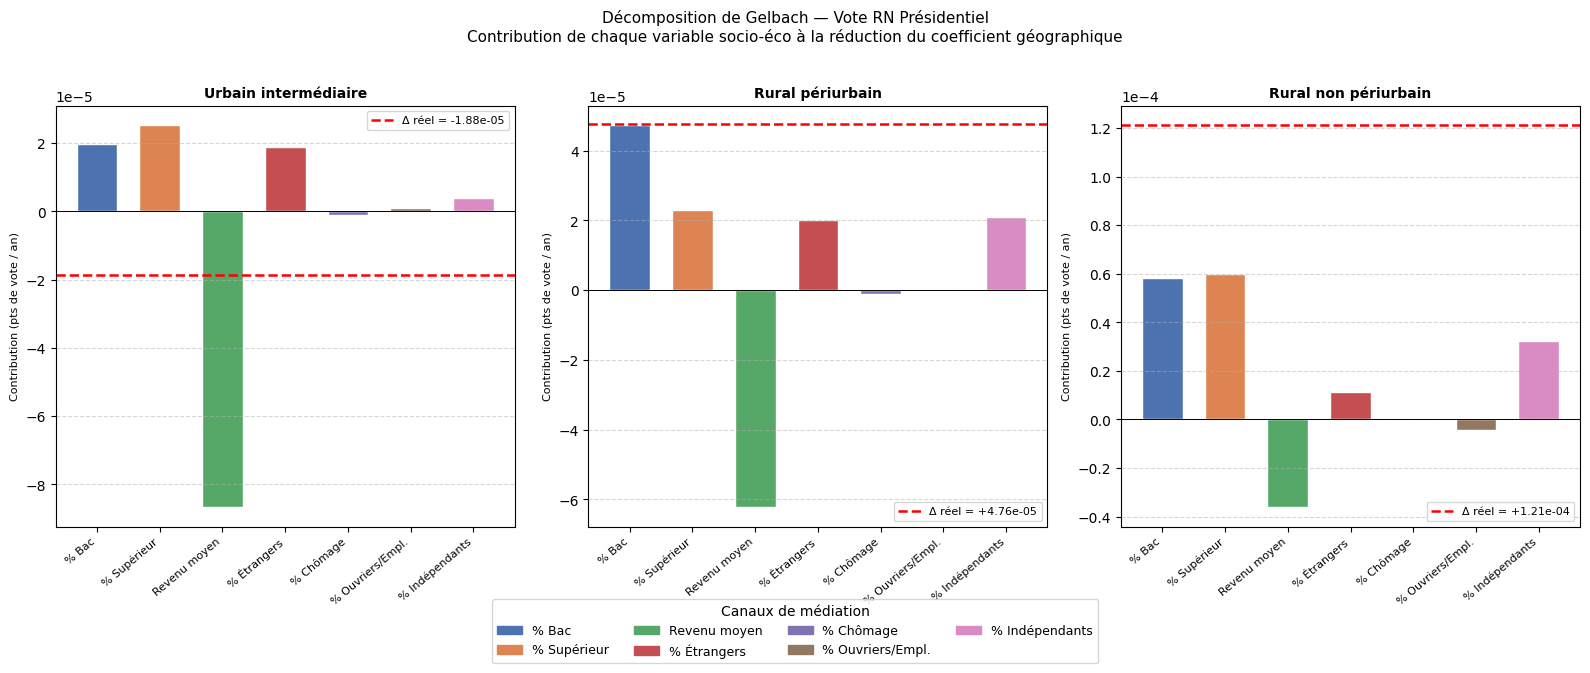

DÉCOMPOSITION DE GELBACH — Vote RN Législatif

Variable géo                     β_naïf   β_contrôlé     Δ réel
--------------------------------------------------------------
Urbain intermédiaire             0.0027       0.0027    -0.0000
Rural périurbain                 0.0042       0.0041     0.0000
Rural non périurbain             0.0043       0.0042     0.0001

Décomposition de l'écart Δ = β_naïf − β_contrôlé

► Urbain intermédiaire  (Δ réel = -0.0000)
  Canal                       δ_k      Γ_gk   Contribution      % Δ
  --------------------------------------------------------------
  % Bac                    0.0220    0.0009         0.0000   -59.3%
  % Supérieur             -0.0277   -0.0006         0.0000   -54.0%
  Revenu moyen            -0.0000   49.3947        -0.0001   235.2%
  % Étrangers             -0.0045   -0.0010         0.0000   -14.0%
  % Chômage                0.0041   -0.0003        -0.0000     4.0%
  % Ouvriers/Empl.        -0.0053   -0.0006         0.0000   -10.0%

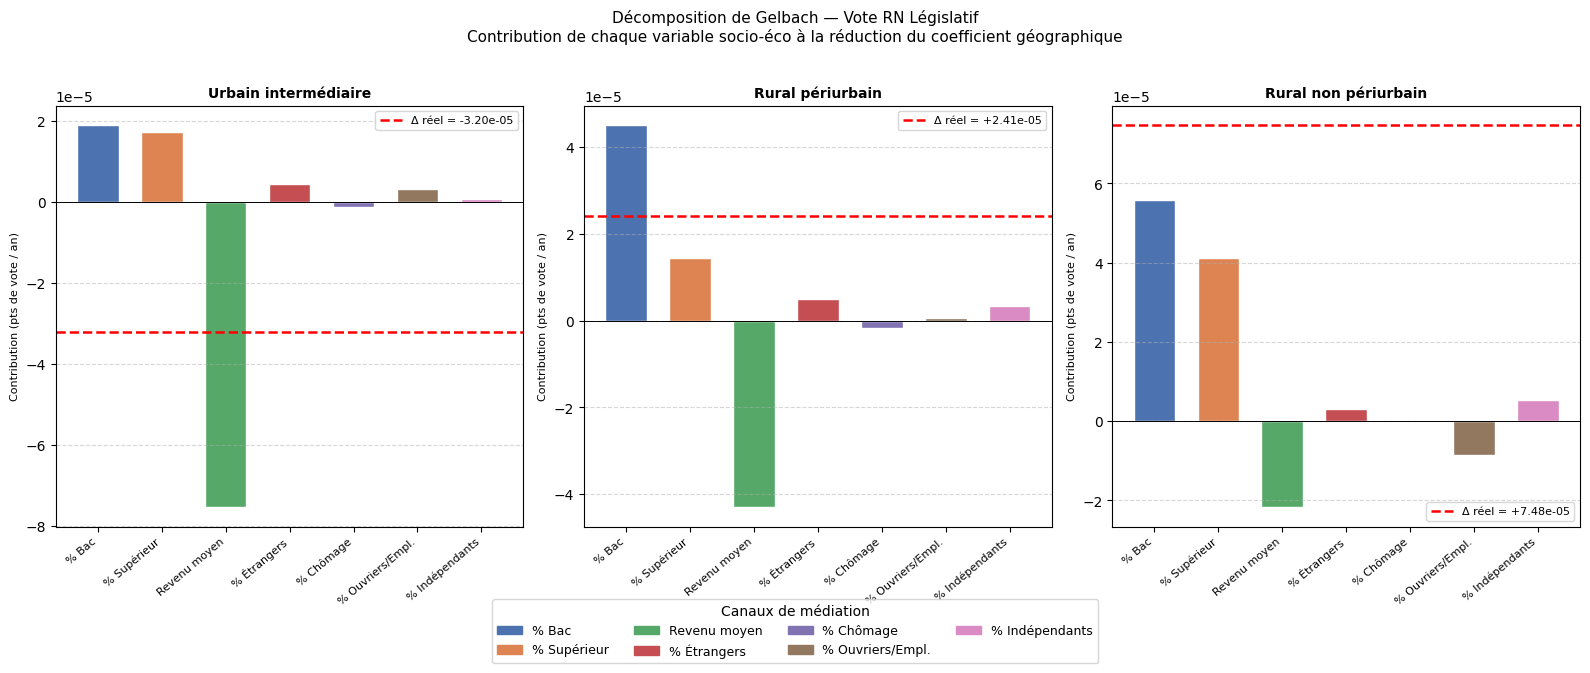

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from linearmodels.panel import PanelOLS

# ============================================================
# DÉCOMPOSITION DE GELBACH — Formalisation
# ============================================================
# Identité exacte : β_naïf - β_contrôlé = Σ_k  δ_k * Γ_gk
#
#   δ_k   = coeff. de la variable socio-éco k dans le modèle COMPLET
#   Γ_gk  = coeff. de la variable géo g dans la régression auxiliaire
#             qui régresse k sur toutes les vars géo + effets fixes
#
# On itère sur les deux votes (présidentiel et législatif).
# ============================================================

CONTROLS = ['pbac', 'psup', 'revmoy', 'petranger', 'pchom', 'pouem', 'paind']
GEO_VARS = ['tend_urbain_inter', 'tend_rural_peri', 'tend_rural_non_peri']

LABELS_GEO = {
    'tend_urbain_inter':   'Urbain intermédiaire',
    'tend_rural_peri':     'Rural périurbain',
    'tend_rural_non_peri': 'Rural non périurbain',
}

LABELS_CONTROLS = {
    'pbac':      '% Bac',
    'psup':      '% Supérieur',
    'revmoy':    'Revenu moyen',
    'petranger': '% Étrangers',
    'pchom':     '% Chômage',
    'pouem':     '% Ouvriers/Empl.',
    'paind':     '% Indépendants',
}

COLORS = {
    'pbac':      '#4C72B0',
    'psup':      '#DD8452',
    'revmoy':    '#55A868',
    'petranger': '#C44E52',
    'pchom':     '#8172B2',
    'pouem':     '#937860',
    'paind':     '#DA8BC3',
}


def gelbach_decomposition(data, dep_var, label):
    """
    Applique la décomposition de Gelbach sur la variable dépendante dep_var.
    Retourne un dict {geo_var: {control: contribution}}.
    """
    # ── Préparation du panel ────────────────────────────────────
    df = data.dropna(
        subset=[dep_var, 'typologie_urbaine', 'Annee', 'codecommune'] + CONTROLS
    ).copy()

    annee_min = df['Annee'].min()
    df['tendance']             = df['Annee'] - annee_min
    df['tend_urbain_inter']    = (df['typologie_urbaine'] == 'Urbain intermédiaire') * df['tendance']
    df['tend_rural_peri']      = (df['typologie_urbaine'] == 'Rural périurbain')      * df['tendance']
    df['tend_rural_non_peri']  = (df['typologie_urbaine'] == 'Rural non périurbain')  * df['tendance']

    panel = df.set_index(['codecommune', 'Annee'])

    # ── Modèle naïf (sans contrôles) ───────────────────────────
    f_naive = (f'{dep_var} ~ 1 + tend_urbain_inter + tend_rural_peri '
               f'+ tend_rural_non_peri + EntityEffects + TimeEffects')
    res_naive = PanelOLS.from_formula(f_naive, data=panel, drop_absorbed=True).fit(
        cov_type='clustered', cluster_entity=True)

    # ── Modèle complet (avec contrôles) ────────────────────────
    ctrl_str = ' + '.join(CONTROLS)
    f_full = (f'{dep_var} ~ 1 + tend_urbain_inter + tend_rural_peri '
              f'+ tend_rural_non_peri + {ctrl_str} + EntityEffects + TimeEffects')
    res_full = PanelOLS.from_formula(f_full, data=panel, drop_absorbed=True).fit(
        cov_type='clustered', cluster_entity=True)

    # ── Régressions auxiliaires ─────────────────────────────────
    # Pour chaque contrôle k : régresser k sur les 3 vars géo + FE
    # On récupère Γ_gk = coeff de la var géo g dans cette régression
    gamma = {}          # gamma[k][geo] = Γ_gk
    for k in CONTROLS:
        f_aux = (f'{k} ~ 1 + tend_urbain_inter + tend_rural_peri '
                 f'+ tend_rural_non_peri + EntityEffects + TimeEffects')
        res_aux = PanelOLS.from_formula(f_aux, data=panel, drop_absorbed=True).fit(
            cov_type='clustered', cluster_entity=True)
        gamma[k] = {g: res_aux.params[g] for g in GEO_VARS}

    # ── Calcul des contributions ────────────────────────────────
    # Contribution de k à la réduction du coeff géo g :
    #   contrib(k, g) = δ_k * Γ_gk
    results = {}
    for g in GEO_VARS:
        results[g] = {}
        for k in CONTROLS:
            delta_k = res_full.params[k]        # effet de k sur vote RN
            gamma_gk = gamma[k][g]              # lien géo → k
            results[g][k] = delta_k * gamma_gk

    # ── Affichage texte ─────────────────────────────────────────
    print("=" * 70)
    print(f"DÉCOMPOSITION DE GELBACH — {label}")
    print("=" * 70)
    print(f"\n{'Variable géo':<30} {'β_naïf':>8} {'β_contrôlé':>12} {'Δ réel':>10}")
    print("-" * 62)
    for g in GEO_VARS:
        bn = res_naive.params[g]
        bf = res_full.params[g]
        print(f"{LABELS_GEO[g]:<30} {bn:>8.4f} {bf:>12.4f} {bn - bf:>10.4f}")

    print("\n" + "=" * 70)
    print("Décomposition de l'écart Δ = β_naïf − β_contrôlé")
    print("=" * 70)

    for g in GEO_VARS:
        beta_naive = res_naive.params[g]
        beta_full  = res_full.params[g]
        delta_real = beta_naive - beta_full

        print(f"\n► {LABELS_GEO[g]}  (Δ réel = {delta_real:+.4f})")
        print(f"  {'Canal':<22} {'δ_k':>8}  {'Γ_gk':>8}  {'Contribution':>13}  {'% Δ':>7}")
        print(f"  {'-'*62}")
        total = 0
        for k in CONTROLS:
            dk   = res_full.params[k]
            ggk  = gamma[k][g]
            cb   = results[g][k]
            pct  = cb / delta_real * 100 if delta_real != 0 else float('nan')
            print(f"  {LABELS_CONTROLS[k]:<22} {dk:>8.4f}  {ggk:>8.4f}  {cb:>13.4f}  {pct:>6.1f}%")
            total += cb
        print(f"  {'─'*62}")
        print(f"  {'TOTAL (vérif.)':<22} {'':>8}  {'':>8}  {total:>13.4f}  {'≈100%':>7}")
        print(f"  {'Δ réel':<22} {'':>8}  {'':>8}  {delta_real:>13.4f}")
        print(f"  → Erreur de vérification : {abs(total - delta_real):.2e}")

    # ── Graphique ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

    for ax, g in zip(axes, GEO_VARS):
        contribs   = results[g]
        vals       = [contribs[k] for k in CONTROLS]
        cols       = [COLORS[k] for k in CONTROLS]
        x_pos      = np.arange(len(CONTROLS))

        bars = ax.bar(x_pos, vals, color=cols, edgecolor='white', width=0.65)

        # Ligne Δ réel (doit coïncider avec la somme des barres)
        delta_real = res_naive.params[g] - res_full.params[g]
        ax.axhline(delta_real, color='red', linewidth=1.8, linestyle='--',
                   label=f'Δ réel = {delta_real:+.2e}')
        ax.axhline(0, color='black', linewidth=0.7)

        ax.set_title(LABELS_GEO[g], fontsize=10, fontweight='bold')
        ax.set_ylabel('Contribution (pts de vote / an)', fontsize=8)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([LABELS_CONTROLS[k] for k in CONTROLS],
                           rotation=40, ha='right', fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        # Force la notation scientifique sur l'axe y pour tous les sous-graphes
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    # Légende commune
    patches = [mpatches.Patch(color=COLORS[k], label=LABELS_CONTROLS[k]) for k in CONTROLS]
    fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9,
               title='Canaux de médiation', bbox_to_anchor=(0.5, -0.08))

    plt.suptitle(
        f"Décomposition de Gelbach — {label}\n"
        "Contribution de chaque variable socio-éco à la réduction du coefficient géographique",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()

    return results


# ── Application aux deux votes ──────────────────────────────────────
res_gelbach_pres = gelbach_decomposition(data, 'vote_RN_pres', 'Vote RN Présidentiel')
res_gelbach_leg  = gelbach_decomposition(data, 'vote_RN_leg',  'Vote RN Législatif')


# Evolution Part RN Inexpliquée 

## Elections Prez

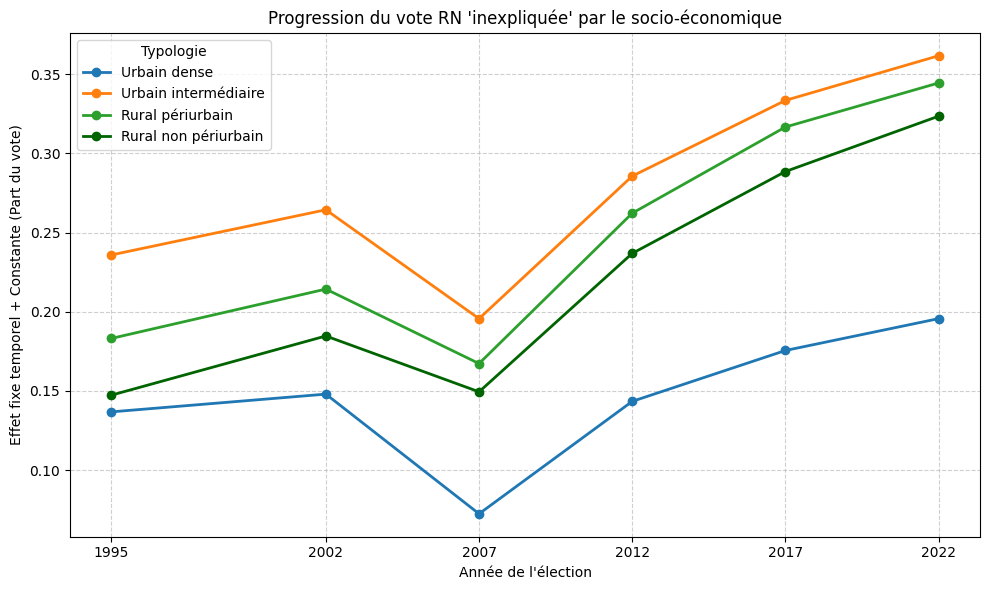

In [26]:
# 1. Nettoyage de base
df_clean = data.dropna(subset=['vote_RN_pres', 'typologie_urbaine', 'Annee', 'codecommune']).copy()

# Pour éviter TOUT bug de nom de variable (KeyError), on crée manuellement les dummies d'années.
# 1995 (ou 1992) est notre année de référence, on ne la crée pas.
annees_estimees = [2002, 2007, 2012, 2017, 2022]
for annee in annees_estimees:
    df_clean[f'annee_{annee}'] = (df_clean['Annee'] == annee).astype(int)

# On configure le Panel
df_panel = df_clean.set_index(['codecommune', 'Annee'])

# Les 4 catégories présentes dans ta base
typologies = ['Urbain dense', 'Urbain intermédiaire', 'Rural périurbain', 'Rural non périurbain']

# Dictionnaire pour stocker les résultats pour le graphique
# On met 1995 comme point de départ
resultats_graphique = {'Année': [1995] + annees_estimees}

# 2. Boucle : Une régression par sous-groupe (typologie)
for typo in typologies:
    # On isole uniquement les communes de ce type
    df_sub = df_panel[df_panel['typologie_urbaine'] == typo]
    
    # Formule avec contrôles (car ton titre de graph dit "inexpliquée par le socio-éco")
    # On ajoute nos dummies d'années manuels + les contrôles + Effet Fixe Commune
    # (Tu peux enlever les contrôles si tu veux le modèle naïf)
    formule = (
        'vote_RN_pres ~ 1 + annee_2002 + annee_2007 + annee_2012 + annee_2017 + annee_2022 + '
        'pbac + psup + revmoy + petranger + pchom + pouem + paind + EntityEffects'
    )
    
    # On fait tomber les NaN spécifiques aux contrôles sur ce sous-groupe
    df_sub_clean = df_sub.dropna(subset=['pbac', 'psup', 'revmoy', 'petranger', 'pchom', 'pouem', 'paind'])
    
    mod = PanelOLS.from_formula(formule, data=df_sub_clean, drop_absorbed=True)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    
    # 3. Extraction pour le graphique
    # L'ordonnée à l'origine (Intercept) nous donne le niveau moyen de base en 1995
    base_1995 = res.params['Intercept']
    
    # On ajoute le coefficient de chaque année à la base de 1995 pour avoir le niveau réel
    trajectoire = [base_1995] # Premier point : 1995
    for annee in annees_estimees:
        niveau_annee = base_1995 + res.params[f'annee_{annee}']
        trajectoire.append(niveau_annee)
        
    # On sauvegarde la trajectoire pour cette typologie
    resultats_graphique[typo] = trajectoire

# 4. Dessin du graphique (style identique à ta capture)
df_plot = pd.DataFrame(resultats_graphique).set_index('Année')

fig, ax = plt.subplots(figsize=(10, 6))

# Couleurs pour différencier urbain/rural (tu peux ajuster)
couleurs = {
    'Urbain dense': '#1f77b4',          # Bleu
    'Urbain intermédiaire': '#ff7f0e',  # Orange
    'Rural périurbain': '#2ca02c',      # Vert clair
    'Rural non périurbain': '#006400'   # Vert foncé
}

# Tracé des lignes
for typo in typologies:
    ax.plot(df_plot.index, df_plot[typo], marker='o', label=typo, color=couleurs[typo], linewidth=2)

# Esthétique
ax.set_title("Progression du vote RN 'inexpliquée' par le socio-économique")
ax.set_ylabel("Effet fixe temporel + Constante (Part du vote)")
ax.set_xlabel("Année de l'élection")
ax.set_xticks(resultats_graphique['Année']) # Force l'affichage de tes années exactes
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Typologie')

plt.tight_layout()
plt.show()

## Elections Leg

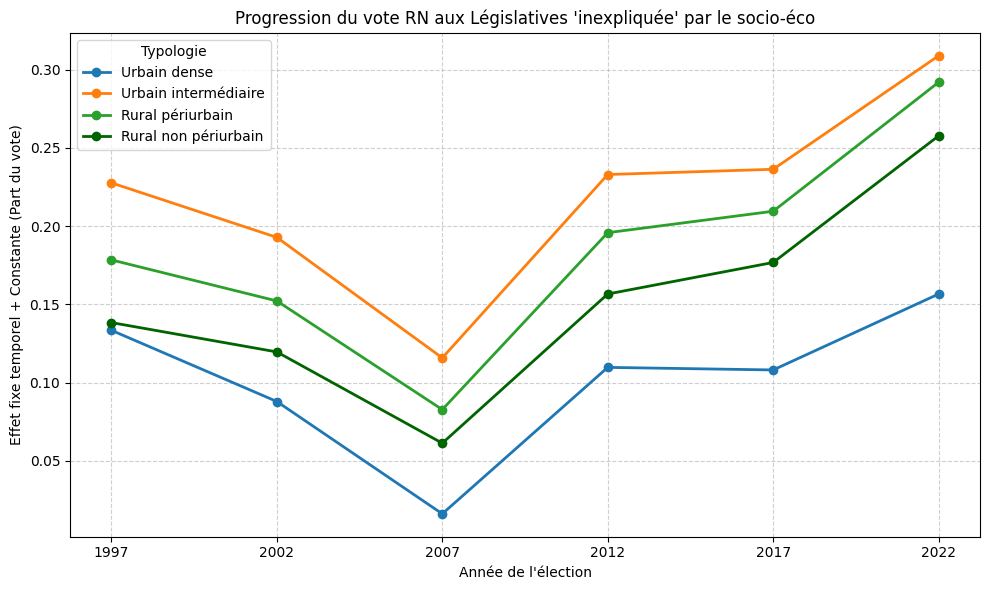

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

# 1. Nettoyage de base (ATTENTION : on cible bien vote_RN_leg ici !)
df_clean = data.dropna(subset=['vote_RN_leg', 'typologie_urbaine', 'Annee', 'codecommune']).copy()

# 2. Détection dynamique des années d'élection législative
# On récupère toutes les années dispo pour les législatives et on les trie
annees_dispo = sorted(df_clean['Annee'].unique())
annee_ref = annees_dispo[0]            # La plus ancienne devient l'année de référence (ex: 1993 ou 1997)
annees_estimees = annees_dispo[1:]     # Les autres seront nos dummies estimées

# Création des dummies d'années (sans l'année de ref)
for annee in annees_estimees:
    df_clean[f'annee_{annee}'] = (df_clean['Annee'] == annee).astype(int)

# On configure le Panel
df_panel = df_clean.set_index(['codecommune', 'Annee'])

# Les 4 catégories présentes dans ta base
typologies = ['Urbain dense', 'Urbain intermédiaire', 'Rural périurbain', 'Rural non périurbain']

# Dictionnaire pour stocker les résultats pour le graphique
resultats_graphique = {'Année': [annee_ref] + annees_estimees}

# 3. Boucle : Une régression par sous-groupe (typologie)
for typo in typologies:
    df_sub = df_panel[df_panel['typologie_urbaine'] == typo]
    
    # On fait tomber les NaN spécifiques aux contrôles sur ce sous-groupe
    df_sub_clean = df_sub.dropna(subset=['pbac', 'psup', 'revmoy', 'petranger', 'pchom', 'pouem', 'paind'])
    
    # Création dynamique de la partie "années" de la formule
    formule_annees = ' + '.join([f'annee_{a}' for a in annees_estimees])
    
    # Formule avec contrôles socio-économiques
    formule = f'vote_RN_leg ~ 1 + {formule_annees} + pbac + psup + revmoy + petranger + pchom + pouem + paind + EntityEffects'
    
    mod = PanelOLS.from_formula(formule, data=df_sub_clean, drop_absorbed=True)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    
    # Extraction pour le graphique
    base_ref = res.params['Intercept']
    
    trajectoire = [base_ref] # Premier point : l'année de référence
    for annee in annees_estimees:
        niveau_annee = base_ref + res.params[f'annee_{annee}']
        trajectoire.append(niveau_annee)
        
    # On sauvegarde la trajectoire pour cette typologie
    resultats_graphique[typo] = trajectoire

# 4. Dessin du graphique
df_plot = pd.DataFrame(resultats_graphique).set_index('Année')

fig, ax = plt.subplots(figsize=(10, 6))

couleurs = {
    'Urbain dense': '#1f77b4',          
    'Urbain intermédiaire': '#ff7f0e',  
    'Rural périurbain': '#2ca02c',      
    'Rural non périurbain': '#006400'   
}

# Tracé des lignes
for typo in typologies:
    ax.plot(df_plot.index, df_plot[typo], marker='o', label=typo, color=couleurs[typo], linewidth=2)

# Esthétique
ax.set_title("Progression du vote RN aux Législatives 'inexpliquée' par le socio-éco")
ax.set_ylabel("Effet fixe temporel + Constante (Part du vote)")
ax.set_xlabel("Année de l'élection")
ax.set_xticks(resultats_graphique['Année']) # S'adapte tout seul aux années des législatives !
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Typologie')

plt.tight_layout()
plt.show()